In [ ]:
str_to_float = float("3.14")
print(str_to_float, type(str_to_float))  # "3.14" -> 3.14, decimal is kept

float_to_int = int(3.99)
print(float_to_int, type(float_to_int))  # 3.99 -> 3, decimal part is truncated (not rounded)

3.14 <class 'float'>
3 <class 'int'>


In [ ]:
model_name = "resnet50"
accuracy = 0.9123
epoch_count = 12

print(f"{model_name} reached {accuracy:.1%} accuracy after {epoch_count} epochs.")

resnet50 reached 91.2% accuracy after 12 epochs.


In [ ]:
accuracy = 0.91
latency_ms = 120

if accuracy >= 0.9 and latency_ms <= 150:
    decision = "ship it"
elif latency_ms > 150:
    decision = "too slow"
else:
    decision = "keep training"

print(decision)

ship it


In [ ]:
scores = [0.62, 0.75, 0.81, 0.88]

for epoch, score in enumerate(scores):
    print(f"epoch {epoch}: {score}")

epoch 0: 0.62
epoch 1: 0.75
epoch 2: 0.81
epoch 3: 0.88


In [ ]:
model_names = ["resnet50", "vgg16", "mobilenet"]          # list: ordered, may be filtered/reordered later
model_shape = (224, 224, 3)                                # tuple: fixed shape that should not change
hyperparams = {"lr": 0.001, "epochs": 10, "batch_size": 32}  # dict: named settings looked up by key
unique_labels = {"cat", "dog", "bird"}                     # set: only membership matters, no duplicates

print(model_names, type(model_names))
print(model_shape, type(model_shape))
print(hyperparams, type(hyperparams))
print(unique_labels, type(unique_labels))

['resnet50', 'vgg16', 'mobilenet'] <class 'list'>
(224, 224, 3) <class 'tuple'>
{'lr': 0.001, 'epochs': 10, 'batch_size': 32} <class 'dict'>
{'cat', 'bird', 'dog'} <class 'set'>


In [ ]:
scores = [0.55, 0.62, 0.81, 0.9, 0.35, 0.88]

passing_scores = [s for s in scores if s >= 0.8]
print(passing_scores)

pass_fail = {s: ("pass" if s >= 0.8 else "fail") for s in scores}
print(pass_fail)

[0.81, 0.9, 0.88]
{0.55: 'fail', 0.62: 'fail', 0.81: 'pass', 0.9: 'pass', 0.35: 'fail', 0.88: 'pass'}


In [ ]:
def normalise(values, minimum=None, maximum=None):
    """Scale a list of numbers into the 0-1 range.

    Args:
        values (list[float]): The numbers to scale.
        minimum (float, optional): Lower bound to scale against. If None, uses min(values).
        maximum (float, optional): Upper bound to scale against. If None, uses max(values).

    Returns:
        list[float]: Values scaled to the 0-1 range. If every value is identical
        (so maximum == minimum), returns a list of 0.0s instead of dividing by zero.
    """
    if not values:
        return []

    lo = minimum if minimum is not None else min(values)
    hi = maximum if maximum is not None else max(values)

    if hi == lo:
        return [0.0 for _ in values]

    return [(v - lo) / (hi - lo) for v in values]


print(normalise([12, 18, 25, 40]))
print(normalise([5, 5, 5, 5]))  # all identical -> no division by zero

[0.0, 0.21428571428571427, 0.4642857142857143, 1.0]
[0.0, 0.0, 0.0, 0.0]


In [ ]:
def summarise_scores(scores):
    """Summarise a list of numeric scores.

    Args:
        scores (list[float]): The scores to summarise.

    Returns:
        dict: count, mean, minimum, maximum, and above_threshold (scores >= 0.8).
        For an empty list, count and above_threshold are 0, and mean/minimum/maximum
        are None since there is nothing to average or compare.
    """
    if not scores:
        return {
            "count": 0,
            "mean": None,
            "minimum": None,
            "maximum": None,
            "above_threshold": 0,
        }

    return {
        "count": len(scores),
        "mean": sum(scores) / len(scores),
        "minimum": min(scores),
        "maximum": max(scores),
        "above_threshold": sum(1 for s in scores if s >= 0.8),
    }


print(summarise_scores([0.6, 0.75, 0.81, 0.9, 0.5]))
print(summarise_scores([]))  # empty input handled without crashing

{'count': 5, 'mean': 0.712, 'minimum': 0.5, 'maximum': 0.9, 'above_threshold': 2}
{'count': 0, 'mean': None, 'minimum': None, 'maximum': None, 'above_threshold': 0}


In [ ]:
def safe_divide(numerator, denominator, default=0.0):
    """Divide two numbers, falling back to a default on bad input.

    Args:
        numerator (float): The value to divide.
        denominator (float): The value to divide by.
        default (float, optional): Value returned when the denominator is zero
            or either input is not numeric. Defaults to 0.0.

    Returns:
        float: numerator / denominator, or default if that division is impossible.
    """
    try:
        return numerator / denominator
    except ZeroDivisionError:
        return default
    except TypeError:
        return default


print(safe_divide(10, 2))       # normal case
print(safe_divide(10, 0))       # divide-by-zero case
print(safe_divide(10, "oops"))  # text-input case

5.0
0.0
0.0


In [ ]:
def train(*args, **kwargs):
    """Stretch: print positional and keyword arguments, train()-style."""
    print(f"args: {args}")
    print(f"kwargs: {kwargs}")


train("resnet50", epochs=10, lr=0.001, batch_size=32)

args: ('resnet50',)
kwargs: {'epochs': 10, 'lr': 0.001, 'batch_size': 32}


In [ ]:
import numpy as np

arr = np.array([4, 8, 15, 16, 23, 42])
print("mean:", arr.mean())
print("std:", arr.std())
print("min:", arr.min())
print("max:", arr.max())

mean: 18.0
std: 12.315302134607444
min: 4
max: 42


In [ ]:
matrix = np.arange(12).reshape(3, 4)
print("shape:", matrix.shape)
print("transpose shape:", matrix.T.shape)

shape: (3, 4)
transpose shape: (4, 3)


In [ ]:
col_means = matrix.mean(axis=0)
centered = matrix - col_means  # broadcasting subtracts col means from every row
print(centered)

[[-4. -4. -4. -4.]
 [ 0.  0.  0.  0.]
 [ 4.  4.  4.  4.]]


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "model": ["resnet50", "vgg16", "mobilenet", "efficientnet", "densenet", None],
    "accuracy": [0.91, 0.87, 0.83, 0.94, np.nan, 0.79],
    "latency_ms": [120, 210, 60, 150, 95, 300],
    "framework": ["torch", "torch", "tf", "torch", "tf", "tf"],
})
df

,model,accuracy,latency_ms,framework
0,resnet50,0.91,120,torch
1,vgg16,0.87,210,torch
2,mobilenet,0.83,60,tf
3,efficientnet,0.94,150,torch
4,densenet,NaN,95,tf
5,NaN,0.79,300,tf


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   model       5 non-null      str    
 1   accuracy    5 non-null      float64
 2   latency_ms  6 non-null      int64  
 3   framework   6 non-null      str    
dtypes: float64(1), int64(1), str(2)
memory usage: 324.0 bytes


In [ ]:
df.describe()

,accuracy,latency_ms
count,5.000000,6.000000
mean,0.868000,155.833333
std,0.060166,87.087121
min,0.790000,60.000000
25%,0.830000,101.250000
50%,0.870000,135.000000
75%,0.910000,195.000000
max,0.940000,300.000000


In [ ]:
df.isna().sum()

model         1
accuracy      1
latency_ms    0
framework     0
dtype: int64

In [ ]:
fast_models = df[df["latency_ms"] < 150].sort_values("accuracy", ascending=False)
fast_models

,model,accuracy,latency_ms,framework
0,resnet50,0.91,120,torch
2,mobilenet,0.83,60,tf
4,densenet,NaN,95,tf


In [ ]:
df["pass_fail"] = df["accuracy"] >= 0.85
df

,model,accuracy,latency_ms,framework,pass_fail
0,resnet50,0.91,120,torch,True
1,vgg16,0.87,210,torch,True
2,mobilenet,0.83,60,tf,False
3,efficientnet,0.94,150,torch,True
4,densenet,NaN,95,tf,False
5,NaN,0.79,300,tf,False


If this were real data, a missing accuracy value could mean a training run
failed or wasn't logged properly. A missing model name would make that row
impossible to attribute to any experiment, so it may need to be dropped or
investigated before further analysis.

In [ ]:
%matplotlib inline

Matplotlib is building the font cache; this may take a moment.


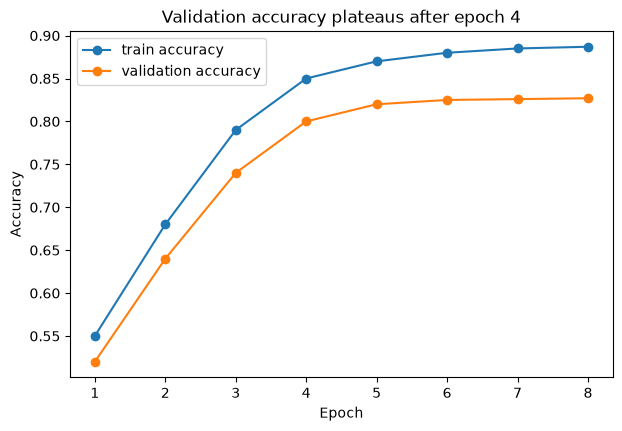

In [ ]:
import matplotlib.pyplot as plt
import os

epochs = [1, 2, 3, 4, 5, 6, 7, 8]
train_acc = [0.55, 0.68, 0.79, 0.85, 0.87, 0.88, 0.885, 0.887]
val_acc =   [0.52, 0.64, 0.74, 0.80, 0.82, 0.825, 0.826, 0.827]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(epochs, train_acc, marker="o", label="train accuracy")
ax.plot(epochs, val_acc, marker="o", label="validation accuracy")

ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Validation accuracy plateaus after epoch 4")
ax.legend()

os.makedirs("../reports", exist_ok=True)
plt.savefig("../reports/day01_chart.png", dpi=150, bbox_inches="tight")
plt.show()